In [1]:
import pandas as pd
import numpy as np
import glob
import re
import os

DATA_FOLDER = "C:/Users/jothi/Downloads/NHS_covid/*.xlsx"


# ---------------------------
# 1. YEAR
# ---------------------------
def extract_year(filepath):
    match = re.search(r'(20\d{2})', filepath)
    return int(match.group(1)) if match else None


# ---------------------------
# 2. HEADER DETECTION
# ---------------------------
def find_header_row(df_raw):
    for i, row in df_raw.iterrows():
        if row.astype(str).str.contains("Admissions", case=False).any():
            return i
    return None


# ---------------------------
# 3. CLEAN COLUMNS
# ---------------------------
def clean_columns(df):
    df.columns = (
        df.columns.astype(str)
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', '_', regex=True)
        .str.replace('-', '_')
        .str.replace('+', 'plus')
    )
    return df


# ---------------------------
# 4. ICD FILTER + Z99 STOP
# ---------------------------
def keep_valid_icd_rows(df):

    df['diagnosis'] = (
        df['diagnosis']
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df = df[df['diagnosis'].str.match(r'^[A-Z][0-9]{2}', na=False)].copy()
    df['icd_code'] = df['diagnosis'].str.extract(r'^([A-Z][0-9]{2})')

    # 🔴 STOP at Z99
    z99_idx = df[df['icd_code'] == 'Z99'].index
    if len(z99_idx) > 0:
        df = df.loc[:z99_idx[0]]

    return df


# ---------------------------
# 5. AGE GROUP FIX
# ---------------------------
def aggregate_age_groups(df):

    age_cols = [c for c in df.columns if c.startswith('age')]

    age_map = {}
    for col in age_cols:
        nums = re.findall(r'\d+', col)

        if len(nums) == 1:
            start = end = int(nums[0])
        elif len(nums) >= 2:
            start, end = int(nums[0]), int(nums[1])
        else:
            continue

        age_map[col] = (start, end)

    def sum_range(min_age, max_age):
        selected = [
            col for col, (s, e) in age_map.items()
            if not (e < min_age or s > max_age)
        ]
        return df[selected].sum(axis=1) if selected else 0

    df['age_0_14'] = sum_range(0, 14)
    df['age_15_59'] = sum_range(15, 59)
    df['age_60_74'] = sum_range(60, 74)
    df['age_75_plus'] = sum_range(75, 120)

    return df


# ---------------------------
# 6. EXTRACT ICD RANGE MAP
# ---------------------------
def extract_icd_ranges(filepath):

    try:
        raw = pd.read_excel(filepath, sheet_name="Primary diagnosis - summary", header=None)
    except:
        return None

    header_row = find_header_row(raw)
    if header_row is None:
        return None

    df = pd.read_excel(filepath, sheet_name="Primary diagnosis - summary", header=header_row)
    df = clean_columns(df)

    # Find diagnosis column
    diagnosis_col = next((c for c in df.columns if "diagnosis" in c), None)
    if diagnosis_col is None:
        return None

    df = df.rename(columns={diagnosis_col: "diagnosis"})

    # 🔴 IMPORTANT: Find description column (next text column)
    text_cols = df.select_dtypes(include='object').columns.tolist()
    text_cols.remove('diagnosis')

    desc_col = text_cols[0] if text_cols else None
    if desc_col is None:
        return None

    df[desc_col] = df[desc_col].astype(str).str.strip()

    # Keep only rows like A00-A09
    range_df = df[df['diagnosis'].str.match(r'^[A-Z]\d{2}\s*[-–]\s*[A-Z]\d{2}', na=False)].copy()

    # Extract start & end
    range_df[['start', 'end']] = range_df['diagnosis'].str.extract(
        r'^([A-Z]\d{2})\s*[-–]\s*([A-Z]\d{2})'
    )

    # 🔴 CORRECT description extraction
    range_df['description'] = range_df[desc_col]

    # Drop empty descriptions
    range_df = range_df[range_df['description'].notna() & (range_df['description'] != '')]

    return range_df[['start', 'end', 'diagnosis', 'description']]


# ---------------------------
# 7. BUILD RANGE MAP
# ---------------------------
def build_icd_range_map():

    files = glob.glob(DATA_FOLDER)
    all_ranges = []

    for f in files:
        r = extract_icd_ranges(f)
        if r is not None:
            all_ranges.append(r)

    if not all_ranges:
        return None

    return pd.concat(all_ranges, ignore_index=True).drop_duplicates()


# ---------------------------
# 8. ICD NUMERIC CONVERSION
# ---------------------------
def icd_to_number(code):
    if pd.isna(code):
        return None
    return (ord(code[0]) - ord('A')) * 100 + int(code[1:])


# ---------------------------
# 9. APPLY ICD MAPPING
# ---------------------------
def apply_icd_mapping(df, range_map):

    # 🔴 REMOVE old columns if they exist
    df = df.drop(columns=['diagnosis_group', 'group_description'], errors='ignore')

    range_map['start_num'] = range_map['start'].apply(icd_to_number)
    range_map['end_num'] = range_map['end'].apply(icd_to_number)

    df['icd_num'] = df['icd_code'].apply(icd_to_number)

    group_labels = []
    group_desc = []

    for val in df['icd_num']:
        assigned = False

        for _, row in range_map.iterrows():
            if val is None:
                continue

            if row['start_num'] <= val <= row['end_num']:
                group_labels.append(row['diagnosis'])
                group_desc.append(row['description'])
                assigned = True
                break

        if not assigned:
            group_labels.append('Other')
            group_desc.append('Other conditions')

    df['diagnosis_group'] = group_labels
    df['group_description'] = group_desc

    return df.drop(columns=['icd_num'])

# ---------------------------
# 10. PROCESS FILE
# ---------------------------
def process_file(filepath):

    try:
        raw = pd.read_excel(filepath, sheet_name="Primary diagnosis - summary", header=None)
    except:
        print("Skipping:", filepath)
        return None

    header_row = find_header_row(raw)
    if header_row is None:
        return None

    df = pd.read_excel(filepath, sheet_name="Primary diagnosis - summary", header=header_row)
    df = df.drop(index=header_row + 1, errors='ignore').reset_index(drop=True)
    df = clean_columns(df)

    diagnosis_col = next((c for c in df.columns if "diagnosis" in c), None)
    if diagnosis_col is None:
        return None

    df = df.rename(columns={diagnosis_col: "diagnosis"})
    df = keep_valid_icd_rows(df)

    # Numeric conversion
    for col in df.columns:
        if col not in ['diagnosis', 'icd_code']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Find columns
    def find_col(k):
        return next((c for c in df.columns if k in c), None)

    admissions_col = find_col('admissions')
    emergency_col = find_col('emergency')
    planned_col = find_col('planned')
    los_col = find_col('length_of_stay')
    wait_col = find_col('time_waited')

    if admissions_col is None:
        return None

    df = aggregate_age_groups(df)

    year = extract_year(filepath)
    df['year'] = year

    df['covid_phase'] = (
        'pre_covid' if year < 2020 else
        'covid_peak' if year in [2020, 2021] else
        'post_covid'
    )

    df['admissions'] = df[admissions_col]
    df['emergency'] = df[emergency_col] if emergency_col else 0
    df['planned'] = df[planned_col] if planned_col else 0
    df['mean_los'] = df[los_col] if los_col else 0
    df['mean_wait'] = df[wait_col] if wait_col else 0

    df['emergency_rate'] = df['emergency'] / df['admissions']
    df['elderly_ratio'] = df['age_75_plus'] / df['admissions']

    df['hospital_pressure_index'] = (
        df['emergency_rate'] *
        df['mean_los'] *
        df['elderly_ratio']
    )

    return df[[
        'diagnosis',
        'icd_code',
        'year',
        'covid_phase',
        'admissions',
        'emergency',
        'planned',
        'mean_los',
        'mean_wait',
        'age_0_14',
        'age_15_59',
        'age_60_74',
        'age_75_plus',
        'emergency_rate',
        'elderly_ratio',
        'hospital_pressure_index'
    ]]



# ---------------------------
# 11. BUILD DATASET
# ---------------------------
def build_dataset():

    files = glob.glob(DATA_FOLDER)
    all_data = []

    for f in files:
        print("Processing:", os.path.basename(f))
        df = process_file(f)

        if df is not None and not df.empty:
            all_data.append(df)

    return pd.concat(all_data, ignore_index=True)


# ---------------------------
# RUN
# ---------------------------
data = build_dataset()

# 🔴 Build ICD mapping from NHS files
range_map = build_icd_range_map()

if range_map is not None:
    data = apply_icd_mapping(data, range_map)
else:
    print("⚠️ ICD mapping not found")

data = data[list(data.columns[-2:]) + list(data.columns[2:-2])]

print("\nFINAL SHAPE:", data.shape)
# print(data[['icd_code', 'diagnosis_group', 'group_description']].head())

data.to_csv("nhs_clean_final.csv", index=False)

Processing: hosp-epis-stat-admi-diag-2018-19-tab.xlsx
Processing: hosp-epis-stat-admi-diag-2019-20-tab supp.xlsx
Processing: hosp-epis-stat-admi-diag-2020-21-tab.xlsx
Processing: hosp-epis-stat-admi-diag-2021-22-tab.xlsx
Processing: hosp-epis-stat-admi-diag-2022-23-tab_V2 (1).xlsx
Processing: hosp-epis-stat-admi-diag-2023-24-tab.xlsx

FINAL SHAPE: (977, 16)


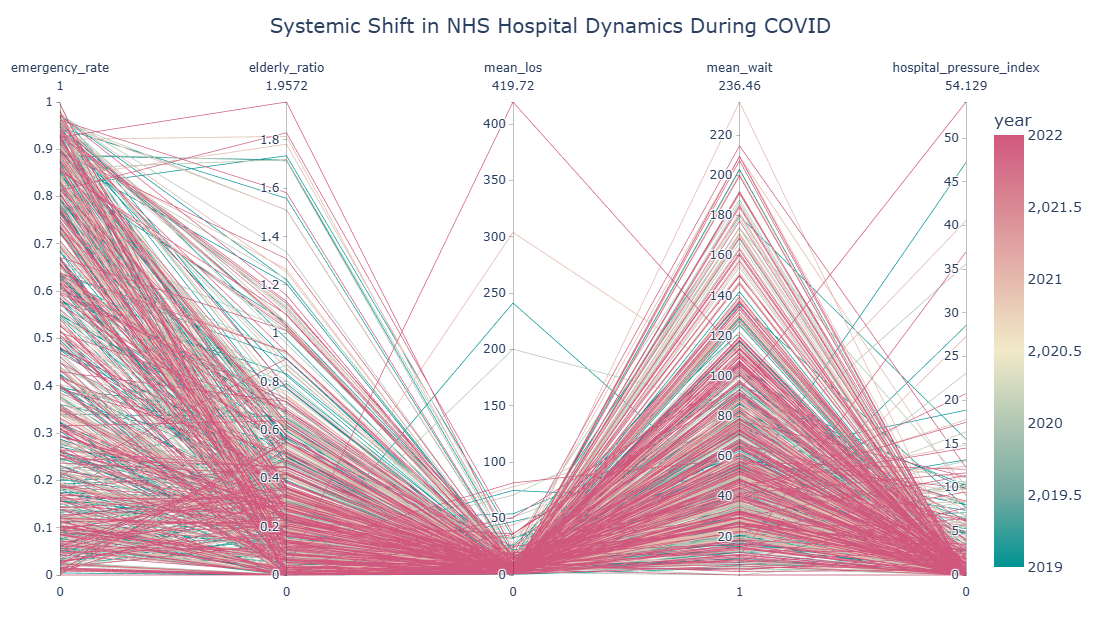

In [2]:
import plotly.express as px

df_vis = data[data['year'] >= 2019]

fig = px.parallel_coordinates(
    df_vis,
    dimensions=[
        'emergency_rate',
        'elderly_ratio',
        'mean_los',
        'mean_wait',
        'hospital_pressure_index'
    ],
    color='year',
    color_continuous_scale=px.colors.diverging.Tealrose
)

fig.update_layout(title= "Systemic Shift in NHS Hospital Dynamics During COVID",
                  title_x=0.5,
                  title_y= 0.97,
    # title={
    #     'text': "Systemic Shift in NHS Hospital Dynamics During COVID",
    #     'y': 0.98,           # Moves title closer to the top edge
    #     'x': 0.5,
    #     'xanchor': 'center',
    #     'yanchor': 'top'
    # },
    font=dict(size=14),
    width=1200, 
    height=600,
    # This creates the space between the title and the feature names
    margin=dict(t=100, b=40, l=60, r=60) 
)

fig.show()

# To handle "DPI" for an export (e.g., for a report)
# Use 'scale' to increase resolution (2 = 2x resolution, 3 = 3x resolution)
# fig.write_image("nhs_dynamics.png", scale=3) 


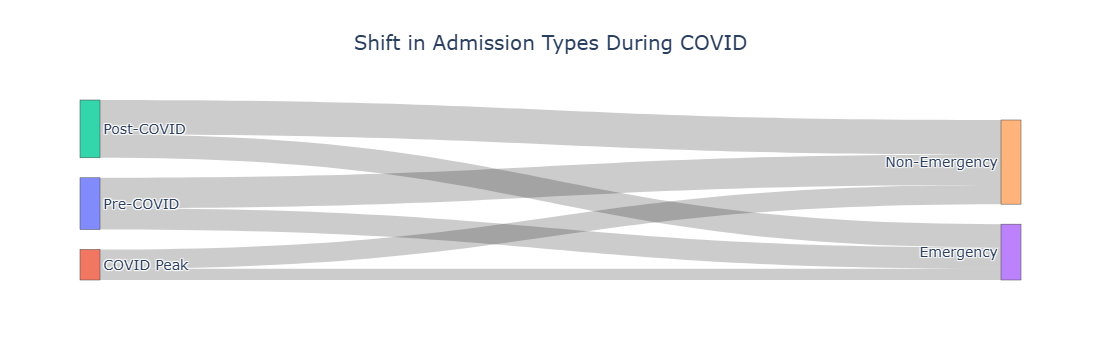

In [3]:
import plotly.graph_objects as go

df_grouped = data.groupby('covid_phase').agg({
    'emergency': 'sum',
    'admissions': 'sum'
}).reset_index()

labels = ['Pre-COVID', 'COVID Peak', 'Post-COVID', 'Emergency', 'Non-Emergency']

source = [0, 1, 2, 0, 1, 2]
target = [3, 3, 3, 4, 4, 4]

values = [
    df_grouped.loc[0, 'emergency'],
    df_grouped.loc[1, 'emergency'],
    df_grouped.loc[2, 'emergency'],
    df_grouped.loc[0, 'admissions'] - df_grouped.loc[0, 'emergency'],
    df_grouped.loc[1, 'admissions'] - df_grouped.loc[1, 'emergency'],
    df_grouped.loc[2, 'admissions'] - df_grouped.loc[2, 'emergency'],
]

fig = go.Figure(go.Sankey(
    node=dict(label=labels),
    link=dict(source=source, target=target, value=values)
))

fig.update_layout(title="Shift in Admission Types During COVID",
                 title_x=0.5,
                 font=dict(size=14))  # center the title
fig.show()

C:\Users\jothi\AppData\Local\Temp\ipykernel_36296\3926157049.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



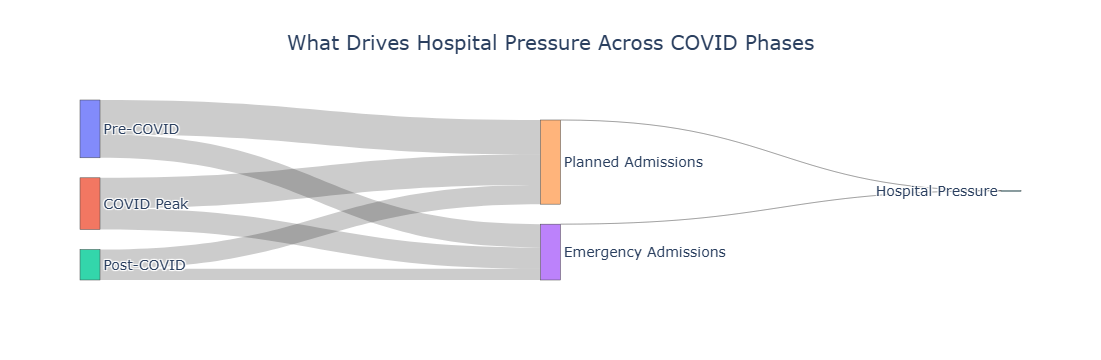

In [4]:
import plotly.graph_objects as go
import pandas as pd

# ---------------------------
# PREP DATA
# ---------------------------
df = data.copy()

# Ensure correct order
phase_order = ['pre_covid', 'covid_peak', 'post_covid']
df['covid_phase'] = pd.Categorical(df['covid_phase'], categories=phase_order, ordered=True)

# Aggregate
df_grouped = df.groupby('covid_phase').agg({
    'admissions': 'sum',
    'emergency': 'sum',
    'hospital_pressure_index': 'sum',
    'age_75_plus': 'sum'
}).reset_index()

# Derived
df_grouped['non_emergency'] = df_grouped['admissions'] - df_grouped['emergency']

# ---------------------------
# NODES
# ---------------------------
labels = [
    'Pre-COVID', 'COVID Peak', 'Post-COVID',
    'Emergency Admissions', 'Planned Admissions',
    'Hospital Pressure'
]

# ---------------------------
# LINKS
# ---------------------------
source = []
target = []
values = []

# Phase → Emergency / Planned
for i in range(3):
    # Emergency
    source.append(i)
    target.append(3)
    values.append(df_grouped.loc[i, 'emergency'])

    # Planned
    source.append(i)
    target.append(4)
    values.append(df_grouped.loc[i, 'non_emergency'])

# Emergency / Planned → Pressure
# Weight pressure contribution proportionally
total_emergency = df_grouped['emergency'].sum()
total_planned = df_grouped['non_emergency'].sum()
total_pressure = df_grouped['hospital_pressure_index'].sum()

emergency_pressure = total_pressure * (total_emergency / (total_emergency + total_planned))
planned_pressure = total_pressure * (total_planned / (total_emergency + total_planned))

source += [3, 4]
target += [5, 5]
values += [emergency_pressure, planned_pressure]

# ---------------------------
# PLOT
# ---------------------------
fig = go.Figure(go.Sankey(
    node=dict(
        label=labels,
        pad=20,
        thickness=20
    ),
    link=dict(
        source=source,
        target=target,
        value=values
    )
))

fig.update_layout(title="What Drives Hospital Pressure Across COVID Phases",
                 title_x=0.5,
                 font=dict(size=14))  # center the title
fig.show()

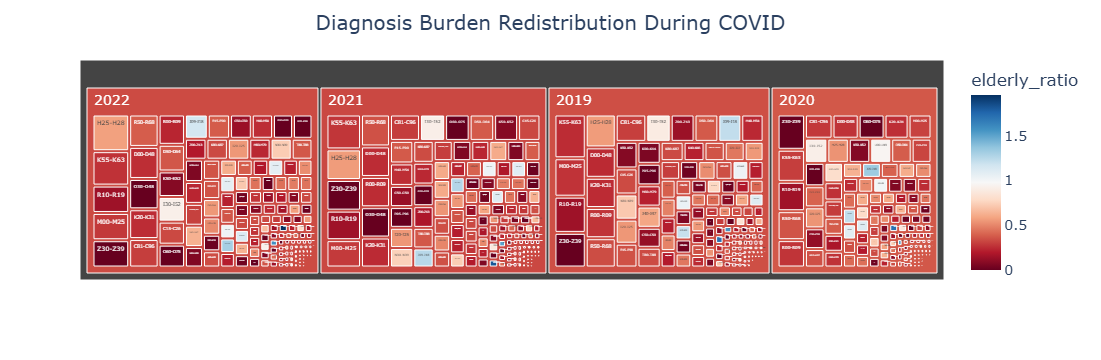

In [5]:
fig = px.treemap(
    data[data['year'] >= 2019],
    path=['year', 'diagnosis_group'],  # show 3-letter code in boxes
    values='admissions',
    color='elderly_ratio',
    color_continuous_scale='RdBu',
    hover_data={
        'group_description': True,   # show full name on hover
        'diagnosis_group': False,    # avoid duplication
        'year': False
    }
)

fig.update_layout(
    title="Diagnosis Burden Redistribution During COVID",
    title_x=0.5,  # center the title
    font=dict(size=14))

# Improve hover formatting
fig.update_traces(
    hovertemplate="<b>%{label}</b><br>" +
                  "Admissions: %{value}<br>" +
                  "Elderly Ratio: %{color:.2f}<br>" +
                  "Description: %{customdata[0]}<extra></extra>"
)

fig.show()